In [ ]:
# SECTION 1: Install Dependencies
!pip install datasets gensim spacy wordcloud -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# SECTION 1B: Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter

# HuggingFace
from datasets import load_dataset

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# SpaCy
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# Gensim
from gensim.models import Word2Vec

# WordCloud
from wordcloud import WordCloud

print("All libraries loaded successfully.")


All libraries loaded successfully.


In [ ]:
# SECTION 2: Load Dataset from HuggingFace
print("Loading dataset...")
dataset = load_dataset("yelp_review_full", split="train[:5000]", trust_remote_code=True)

df = pd.DataFrame({
    "text": dataset["text"],
    "label": dataset["label"]
})

# Labels are 0–4 (stars 1–5)
df["stars"] = df["label"] + 1

print(f"Dataset loaded: {len(df)} reviews")
print(f"\nStar distribution:\n{df['stars'].value_counts().sort_index()}")
print(f"\nSample review:\n{df['text'][0][:300]}")
df.head(3)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'yelp_review_full' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'yelp_review_full' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading dataset...
Dataset loaded: 5000 reviews

Star distribution:
stars
1     883
2    1126
3    1119
4     978
5     894
Name: count, dtype: int64

Sample review:
dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens


,text,label,stars
0,dr. goldberg offers everything i look for in a...,4,5
1,"Unfortunately, the frustration of being Dr. Go...",1,2
2,Been going to Dr. Goldberg for over 10 years. ...,3,4


In [ ]:
# SECTION 3: Text Cleaning
def clean_text(text):
    """Remove HTML, URLs, special characters; lowercase."""
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)           # remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)    # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)       # keep only letters
    text = re.sub(r'\s+', ' ', text)                # collapse whitespace
    text = text.lower().strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

print("Text cleaning complete.")
print("\nOriginal:")
print(df['text'][0][:200])
print("\nCleaned:")
print(df['cleaned_text'][0][:200])

Text cleaning complete.

Original:
dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-no

Cleaned:
dr goldberg offers everything i look for in a general practitioner he s nice and easy to talk to without being patronizing he s always on time in seeing his patients he s affiliated with a top notch h


In [ ]:
# SECTION 4: Tokenization
df['tokens'] = df['cleaned_text'].apply(word_tokenize)

print("Tokenization complete.")
print(f"\nSample tokens (first 20): {df['tokens'][0][:20]}")
print(f"Average tokens per review: {df['tokens'].apply(len).mean():.1f}")

Tokenization complete.

Sample tokens (first 20): ['dr', 'goldberg', 'offers', 'everything', 'i', 'look', 'for', 'in', 'a', 'general', 'practitioner', 'he', 's', 'nice', 'and', 'easy', 'to', 'talk', 'to', 'without']
Average tokens per review: 139.2


In [ ]:
# SECTION 5: Stopword Removal
STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)

# Stats
orig_avg = df['tokens'].apply(len).mean()
filt_avg = df['tokens_no_stop'].apply(len).mean()

print("Stopword removal complete.")
print(f"Average tokens before: {orig_avg:.1f}")
print(f"Average tokens after:  {filt_avg:.1f}  ({100*(orig_avg-filt_avg)/orig_avg:.1f}% removed)")
print(f"\nSample (first 15): {df['tokens_no_stop'][0][:15]}")

Stopword removal complete.
Average tokens before: 139.2
Average tokens after:  66.1  (52.5% removed)

Sample (first 15): ['goldberg', 'offers', 'everything', 'look', 'general', 'practitioner', 'nice', 'easy', 'talk', 'without', 'patronizing', 'always', 'time', 'seeing', 'patients']


In [ ]:
# SECTION 6: Lemmatization using SpaCy
def lemmatize_tokens(tokens):
    """Re-join tokens, run SpaCy, return lemmas."""
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc if not token.is_space]

# SpaCy is slow per-row — batch with nlp.pipe for speed
print("Running lemmatization (this may take ~1–2 min for 5000 reviews)...")

joined = df['tokens_no_stop'].apply(lambda t: " ".join(t)).tolist()
lemma_results = []
for doc in nlp.pipe(joined, batch_size=256):
    lemma_results.append([token.lemma_ for token in doc if not token.is_space and len(token.lemma_) > 2])

df['lemmas'] = lemma_results

# Create a clean string version for vectorizers
df['lemma_text'] = df['lemmas'].apply(lambda x: " ".join(x))

print("Lemmatization complete.")
print(f"\nTokens before lemma: {df['tokens_no_stop'][0][:10]}")
print(f"Lemmas after:        {df['lemmas'][0][:10]}")

Running lemmatization (this may take ~1–2 min for 5000 reviews)...
Lemmatization complete.

Tokens before lemma: ['goldberg', 'offers', 'everything', 'look', 'general', 'practitioner', 'nice', 'easy', 'talk', 'without']
Lemmas after:        ['goldberg', 'offer', 'everything', 'look', 'general', 'practitioner', 'nice', 'easy', 'talk', 'without']


In [ ]:
# SECTION 7: Vocabulary Creation
all_words = [word for tokens in df['lemmas'] for word in tokens]
word_freq = Counter(all_words)

vocab = {word: i for i, (word, _) in enumerate(word_freq.most_common(10000))}

print("Vocabulary created.")
print(f"Total unique words:      {len(word_freq):,}")
print(f"Vocabulary size (top 10k): {len(vocab):,}")
print(f"\nTop 20 most common words:")
for word, count in word_freq.most_common(20):
    print(f"  {word:<20} {count:>6}")

Vocabulary created.
Total unique words:      16,121
Vocabulary size (top 10k): 10,000

Top 20 most common words:
  good                   3871
  get                    3661
  place                  3378
  food                   3219
  like                   2636
  time                   2253
  one                    2169
  order                  2062
  well                   2028
  come                   1852
  would                  1825
  make                   1759
  great                  1740
  really                 1578
  service                1552
  back                   1542
  say                    1540
  take                   1520
  restaurant             1277
  try                    1239


In [ ]:
# SECTION 8: Bag of Words and TF-IDF Vectors

# --- Bag of Words ---
bow_vectorizer = CountVectorizer(max_features=5000, min_df=2, max_df=0.95)
bow_matrix = bow_vectorizer.fit_transform(df['lemma_text'])

# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['lemma_text'])

print("Vectorization complete.")
print(f"BoW matrix shape:   {bow_matrix.shape}")
print(f"TF-IDF matrix shape:{tfidf_matrix.shape}")
print(f"Matrix sparsity:    {100*(1 - bow_matrix.nnz / (bow_matrix.shape[0]*bow_matrix.shape[1])):.2f}%")

# Top TF-IDF terms per document (sample)
feature_names = tfidf_vectorizer.get_feature_names_out()
sample_vec = tfidf_matrix[0].toarray()[0]
top_indices = sample_vec.argsort()[-10:][::-1]
print(f"\nTop TF-IDF terms for review 0:")
for idx in top_indices:
    print(f"  {feature_names[idx]:<20} {sample_vec[idx]:.4f}")

Vectorization complete.
BoW matrix shape:   (5000, 5000)
TF-IDF matrix shape:(5000, 5000)
Matrix sparsity:    99.00%

Top TF-IDF terms for review 0:
  see                  0.2835
  without              0.2496
  specialist           0.2418
  blank                0.2418
  surgery              0.2375
  goldberg             0.2375
  patronize            0.2304
  hospital             0.2067
  draw                 0.2052
  need                 0.1995


In [ ]:
# SECTION 9: Word Embeddings using Gensim Word2Vec
print("Training Word2Vec model...")

w2v_model = Word2Vec(
    sentences=df['lemmas'].tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42
)

w2v_model.save("word2vec_yelp.model")
print("Word2Vec model trained and saved.")
print(f"Vocabulary size: {len(w2v_model.wv):,} words")

# Explore the model
test_words = ['food', 'service', 'price', 'staff']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nWords similar to '{word}':")
        for w, score in similar:
            print(f"  {w:<20} {score:.4f}")

Training Word2Vec model...
Word2Vec model trained and saved.
Vocabulary size: 9,200 words

Words similar to 'food':
  overall              0.7680
  spendy               0.7609
  nfood                0.7464
  outweigh             0.7404
  pricey               0.7273

Words similar to 'service':
  nservice             0.8307
  aloof                0.8191
  extremely            0.7554
  attentive            0.7434
  experience           0.7321

Words similar to 'price':
  quality              0.7769
  expensive            0.7761
  cheap                0.7739
  reasonable           0.7676
  less                 0.7505

Words similar to 'staff':
  helpful              0.8955
  polite               0.8493
  efficient            0.8464
  extremely            0.8416
  genuine              0.8409


In [ ]:
# SECTION 10: Sentence Embeddings (mean-pooled Word2Vec)
def sentence_embedding(tokens, model, vector_size=100):
    """Mean-pool word vectors; return zero vector if no known tokens."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(vector_size)

print("Building sentence embeddings...")
sentence_embeddings = np.vstack([
    sentence_embedding(tokens, w2v_model)
    for tokens in df['lemmas']
])

df['embedding'] = list(sentence_embeddings)

print("Sentence embeddings complete.")
print(f"Embedding matrix shape: {sentence_embeddings.shape}")
print(f"Sample vector (first 10 dims): {sentence_embeddings[0][:10].round(4)}")

Building sentence embeddings...
Sentence embeddings complete.
Embedding matrix shape: (5000, 100)
Sample vector (first 10 dims): [ 0.334   0.0541  0.0169 -0.0662  0.1524  0.3228  0.2984  0.1184 -0.246
 -0.1177]


In [ ]:
# SECTION 11: Similarity Search using Cosine Similarity
def find_similar_reviews(query_idx, embeddings, df, top_k=5):
    """Find top-k most similar reviews to a given index."""
    query_vec = embeddings[query_idx].reshape(1, -1)
    scores = cosine_similarity(query_vec, embeddings)[0]
    scores[query_idx] = -1  # exclude self
    top_indices = scores.argsort()[-top_k:][::-1]

    print(f"{'='*60}")
    print(f"QUERY REVIEW (index {query_idx}, {df['stars'][query_idx]}★):")
    print(f"{df['text'][query_idx][:200]}...")
    print(f"\nTOP {top_k} SIMILAR REVIEWS:")
    for rank, idx in enumerate(top_indices, 1):
        print(f"\n  [{rank}] Index {idx} | {df['stars'][idx]}★ | Score: {scores[idx]:.4f}")
        print(f"  {df['text'][idx][:150]}...")

# Try a few queries
find_similar_reviews(0, sentence_embeddings, df, top_k=3)
print()
find_similar_reviews(42, sentence_embeddings, df, top_k=3)

QUERY REVIEW (index 0, 5★):
dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-no...

TOP 3 SIMILAR REVIEWS:

  [1] Index 341 | 1★ | Score: 0.9723
  Interesting the reviews here are less than stellar already. I would normally not review a chain retail store, but the service I received today just re...

  [2] Index 1069 | 1★ | Score: 0.9612
  I'm in the market for a fun little scooter to have fun and commute on, and at the suggestion of a friend, I went to Bohn Cycle Shop to check out what ...

  [3] Index 1377 | 1★ | Score: 0.9609
  Read my first review... loved this place... Today I stopped in to look around,my niece was with me and I remembered that they had help wanted postings...

QUERY REVIEW (index 42, 5★):
What a find! I stopped in here for breakfast while in town for business. The service is so friendly I thought I was down south. Th

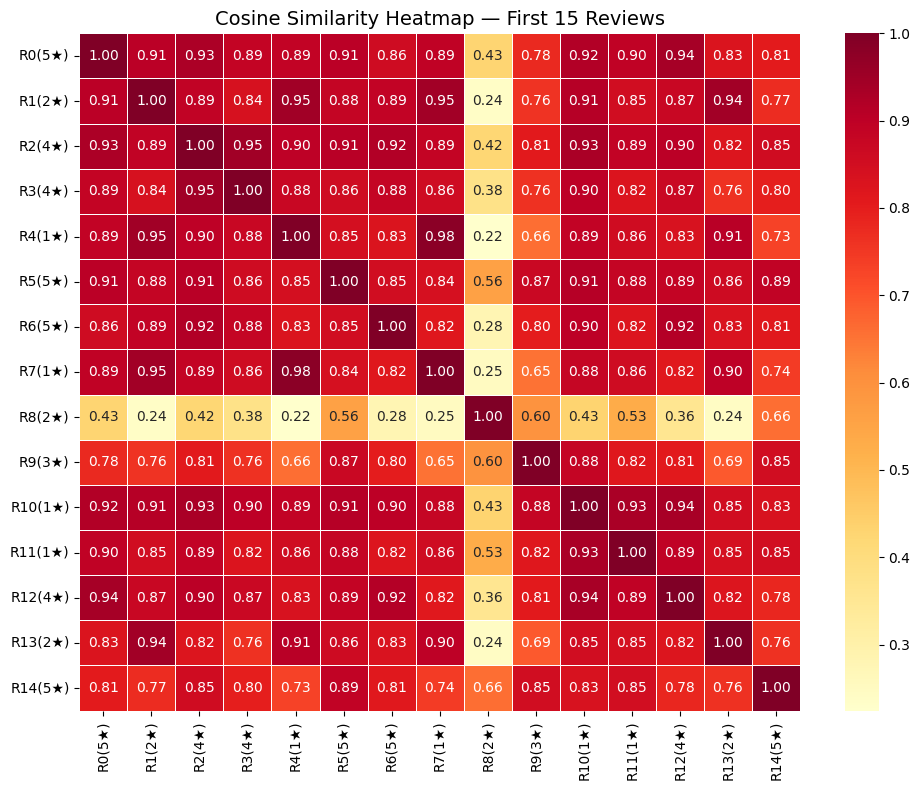

✅ Similarity heatmap saved.


In [ ]:
# --- Cosine similarity heatmap for a small sample ---
sample_size = 15
sample_embeds = sentence_embeddings[:sample_size]
sim_matrix = cosine_similarity(sample_embeds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    xticklabels=[f"R{i}({df['stars'][i]}★)" for i in range(sample_size)],
    yticklabels=[f"R{i}({df['stars'][i]}★)" for i in range(sample_size)],
    linewidths=0.5
)
plt.title("Cosine Similarity Heatmap — First 15 Reviews", fontsize=14)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
plt.show()
print("✅ Similarity heatmap saved.")

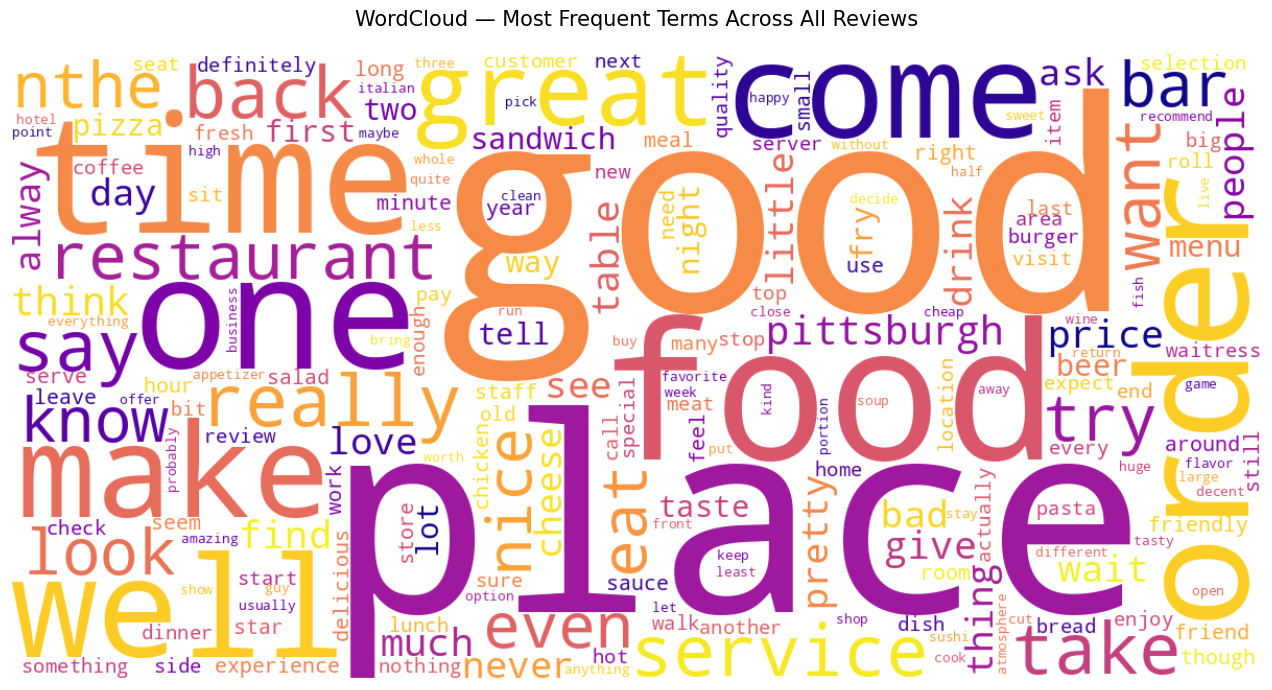

✅ WordCloud saved.


In [ ]:
# SECTION 12A: WordCloud
all_lemma_text = " ".join(df['lemma_text'])

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=200,
    colormap='plasma',
    collocations=False
).generate(all_lemma_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud — Most Frequent Terms Across All Reviews", fontsize=15, pad=20)
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150)
plt.show()
print("✅ WordCloud saved.")

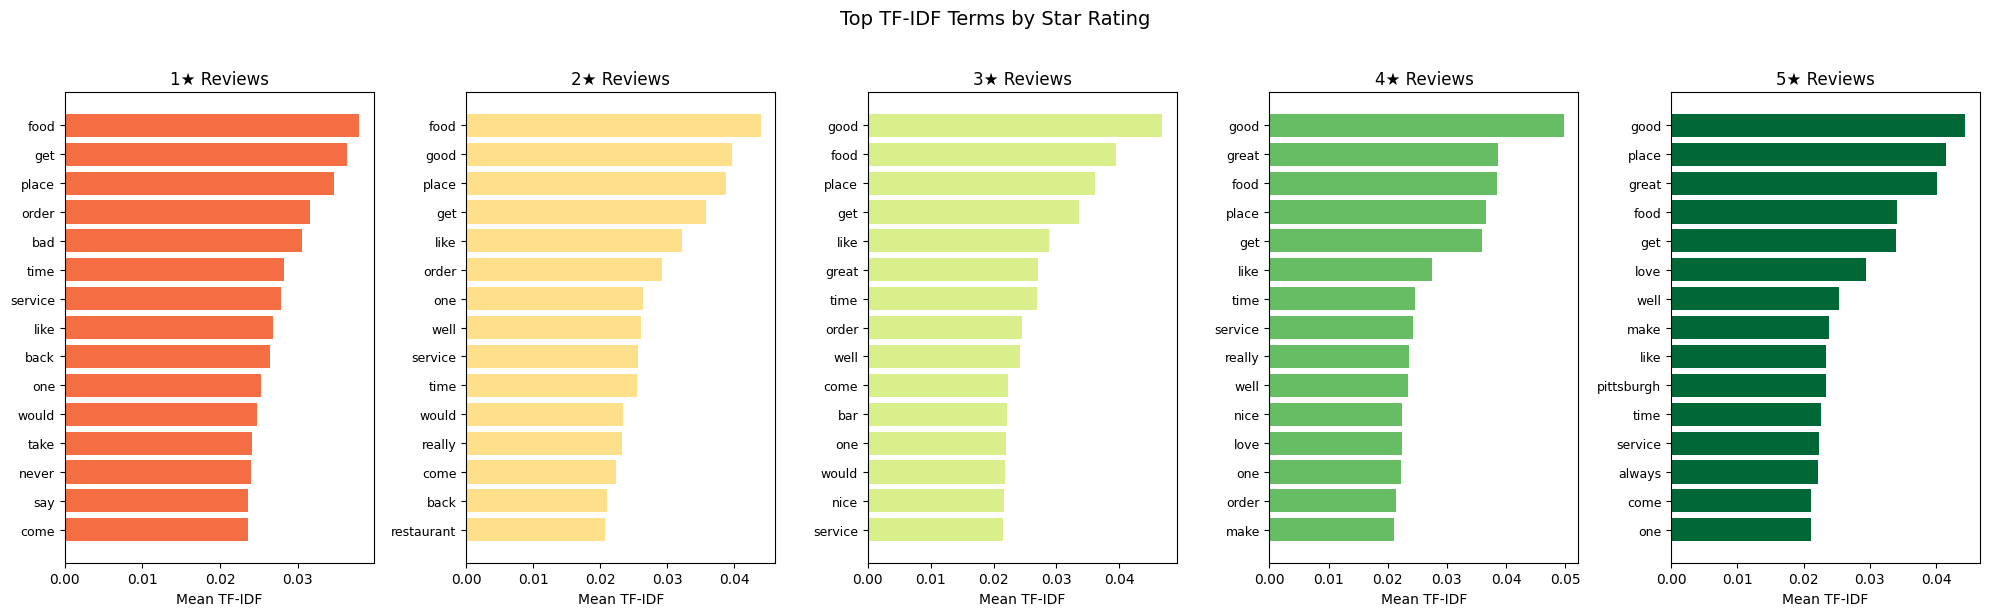

✅ TF-IDF bar chart saved.


In [ ]:
# SECTION 12B: Top TF-IDF Terms per Star Rating

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for star in range(1, 6):
    ax = axes[star - 1]
    subset = df[df['stars'] == star]['lemma_text']

    tfidf_star = TfidfVectorizer(max_features=2000, min_df=2)
    matrix = tfidf_star.fit_transform(subset)

    mean_tfidf = matrix.mean(axis=0).A1
    terms = tfidf_star.get_feature_names_out()
    top_idx = mean_tfidf.argsort()[-15:][::-1]

    ax.barh(
        [terms[i] for i in top_idx][::-1],
        [mean_tfidf[i] for i in top_idx][::-1],
        color=plt.cm.RdYlGn(star / 5)
    )
    ax.set_title(f"{star}★ Reviews", fontsize=12)
    ax.set_xlabel("Mean TF-IDF")
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle("Top TF-IDF Terms by Star Rating", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("tfidf_by_rating.png", dpi=150)
plt.show()
print("✅ TF-IDF bar chart saved.")

Running t-SNE (may take 1–2 min)...


/tmp/ipykernel_2831/2325330300.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(100, len(x)), random_state=42))
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


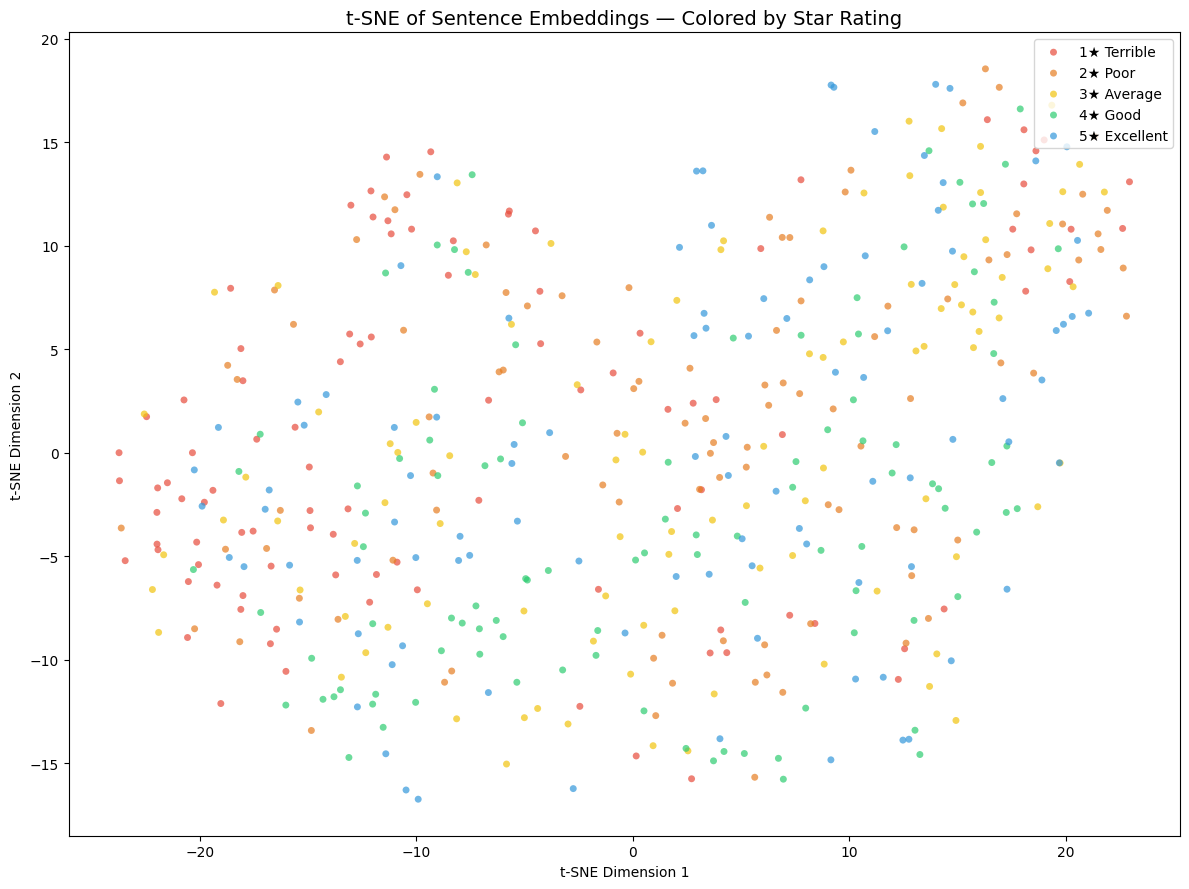

✅ t-SNE plot saved.


In [ ]:
# SECTION 12C: t-SNE Visualization of Sentence Embeddings
print("Running t-SNE (may take 1–2 min)...")

# Use a balanced sample of 500 reviews for clarity
sample_n = 500
sample_idx = (
    df.groupby('stars')
    .apply(lambda x: x.sample(min(100, len(x)), random_state=42))
    .index.get_level_values(1)
)[:sample_n]

sample_embeds_tsne = sentence_embeddings[sample_idx]
sample_stars = df['stars'].iloc[sample_idx].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(sample_embeds_tsne)

plt.figure(figsize=(12, 9))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
labels = ['1★ Terrible', '2★ Poor', '3★ Average', '4★ Good', '5★ Excellent']

for i, (color, label) in enumerate(zip(colors, labels)):
    mask = sample_stars == (i + 1)
    plt.scatter(
        tsne_result[mask, 0], tsne_result[mask, 1],
        c=color, label=label, alpha=0.7, s=25, edgecolors='none'
    )

plt.title("t-SNE of Sentence Embeddings — Colored by Star Rating", fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=150)
plt.show()
print("✅ t-SNE plot saved.")

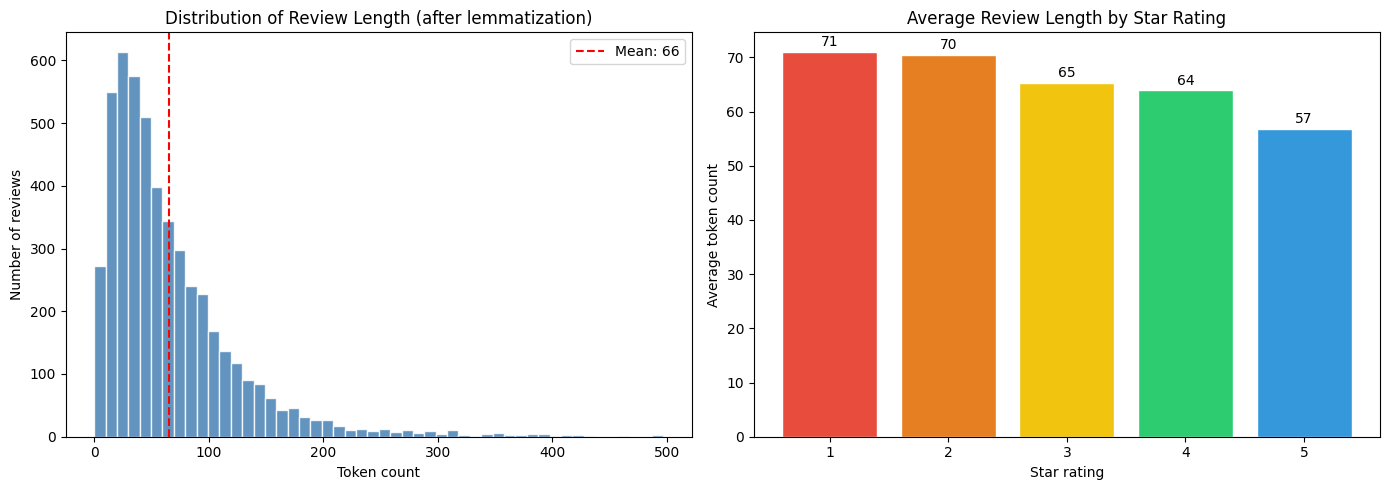

✅ Distribution plots saved.


In [ ]:
# SECTION 12D: Token Distribution & Review Length Stats
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token length distribution
df['token_count'] = df['lemmas'].apply(len)
axes[0].hist(df['token_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['token_count'].mean(), color='red', linestyle='--', label=f"Mean: {df['token_count'].mean():.0f}")
axes[0].set_title("Distribution of Review Length (after lemmatization)", fontsize=12)
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("Number of reviews")
axes[0].legend()

# Average token count by star rating
avg_len = df.groupby('stars')['token_count'].mean()
bars = axes[1].bar(avg_len.index, avg_len.values,
                   color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'],
                   edgecolor='white')
axes[1].set_title("Average Review Length by Star Rating", fontsize=12)
axes[1].set_xlabel("Star rating")
axes[1].set_ylabel("Average token count")
for bar, val in zip(bars, avg_len.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.0f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("token_distribution.png", dpi=150)
plt.show()
print("✅ Distribution plots saved.")

In [ ]:
# SECTION 12E: Final Summary
print("=" * 55)
print("         NLP PIPELINE — SUMMARY REPORT")
print("=" * 55)
print(f"  Dataset:           yelp_review_full (HuggingFace)")
print(f"  Reviews processed: {len(df):,}")
print(f"  Vocabulary size:   {len(word_freq):,} unique words")
print(f"  W2V vocab:         {len(w2v_model.wv):,} words")
print(f"  BoW matrix:        {bow_matrix.shape[0]:,} x {bow_matrix.shape[1]:,}")
print(f"  TF-IDF matrix:     {tfidf_matrix.shape[0]:,} x {tfidf_matrix.shape[1]:,}")
print(f"  Embedding dims:    {sentence_embeddings.shape[1]}")
print(f"  Embedding matrix:  {sentence_embeddings.shape[0]:,} x {sentence_embeddings.shape[1]}")
print("=" * 55)
print("\nFiles saved:")
print("  word2vec_yelp.model")
print("  similarity_heatmap.png")
print("  wordcloud.png")
print("  tfidf_by_rating.png")
print("  tsne_embeddings.png")
print("  token_distribution.png")
print("\n✅ Pipeline complete!")

         NLP PIPELINE — SUMMARY REPORT
  Dataset:           yelp_review_full (HuggingFace)
  Reviews processed: 5,000
  Vocabulary size:   16,121 unique words
  W2V vocab:         9,200 words
  BoW matrix:        5,000 x 5,000
  TF-IDF matrix:     5,000 x 5,000
  Embedding dims:    100
  Embedding matrix:  5,000 x 100

Files saved:
  word2vec_yelp.model
  similarity_heatmap.png
  wordcloud.png
  tfidf_by_rating.png
  tsne_embeddings.png
  token_distribution.png

✅ Pipeline complete!
